# Week 2

> 데이터 불러오기

In [1]:
# 필요한 패키지 불러오기
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/BankChurners.csv')

### TASK 1: 데이터 전처리

#### 1️⃣ 변수 제거

* 고객 ID는 분석에 필요 없으므로 제거
* Naive Bayes 관련 변수 (데이터 제공자가 만든 모델에 의한 이탈 예측 확률값) 제거

In [4]:
df = df.drop(columns=['CLIENTNUM', 
                      'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
                      'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'])

앞서 EDA에서, 정보가 중복되는 변수들이 있었다.

**Credit_Limit & Avg_Open_To_Buy**
* (Avg_Open_To_Buy = Credit_Limit - Total_Revolving_Bal)라는 계산으로 만들어지는 **파생 변수**이므로, 여기서 Avg_Open_To_Buy를 삭제 (관행에 따라)

**Total_Trans_Amt ↔ Total_Trans_Ct**
* 거래 금액과 거래 횟수는 서로 연관이 높지만, 완전히 같은 정보가 아니고 둘 다 중요한 변수이므로 유지

**Total_Amt_Chng_Q4_Q1 & Total_Ct_Chng_Q4_Q1**
* 두 변수 모두 **최근 소비 변화**를 나타낸다. 보통 금액 변화가 이탈률 설명력이 큰 경우가 많다고 하여, Total_Ct_Chng_Q4_Q1를 삭제

**Credit_Limit ↔ Avg_Utilization_Ratio ↔ Avg_Open_To_Buy**
* (Utilization = 사용금액 / Credit_Limit)의 수학적 구조를 가진다.
* 앞서 Avg_Open_To_By 변수는 제거했고, 남은 두 변수는 정보가 다르므로 유지
* Credit_Limit: 고객 신용 수준, Utilization: 카드 사용 패턴

In [5]:
df = df.drop(columns=['Avg_Open_To_Buy', 'Total_Ct_Chng_Q4_Q1'])

#### 2️⃣ 변수명 수정

이름이 너무 길거나, 의미를 알기 어려운 변수 이름 변환.
또한 오류 방지를 위해 모두 소문자로 변환해준다.

In [6]:
df = df.rename(columns={
    'Attrition_Flag':'churn',
    'Customer_Age':'age',
    'Gender':'gender',
    'Dependent_count':'family',
    'Education_Level':'education',
    'Marital_Status':'marriage',
    'Income_Category':'income',
    'Card_Category':'card_category',
    'Months_on_book':'hold_month',
    'Total_Relationship_Count':'product_count',
    'Months_Inactive_12_mon':'inactive_12m',
    'Contacts_Count_12_mon':'contacts_12m',
    'Credit_Limit':'credit_limit',
    'Total_Revolving_Bal':'revolving_balance',
    'Total_Amt_Chng_Q4_Q1':'amt_change_q4_q1',
    'Total_Trans_Amt':'total_trans_amt',
    'Total_Trans_Ct':'total_trans_cnt',
    'Avg_Utilization_Ratio':'utilization_ratio'})

df.head()

,churn,age,gender,family,education,marriage,income,card_category,hold_month,product_count,inactive_12m,contacts_12m,credit_limit,revolving_balance,amt_change_q4_q1,total_trans_amt,total_trans_cnt,utilization_ratio
0,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.0,777,1.335,1144,42,0.061
1,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.0,864,1.541,1291,33,0.105
2,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.0,0,2.594,1887,20,0.000
3,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,3,4,1,3313.0,2517,1.405,1171,20,0.760
4,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.0,0,2.175,816,28,0.000


In [7]:
df.shape

(10127, 18)

> 변수 정리

✏️ **타겟 변수**
* churn: 이탈 여부 (해지하면 1, 유지 중이면 0)

***

✏️ **인구통계학적 변수**
* age: 나이 (만 나이)

* gender: 성별

* family: 부양가족 수

* education: 학력 수준 (예: 고졸, 대졸, 대학원 등)

* marriage: 결혼 상태 (기혼, 미혼, 이혼, 미상)

* income: 연 소득 (소득 구간)

***

✏️ **카드/상품 관련 변수**

* card_category: 카드 등급 (Blue, Silver, Gold, Platinum)

* hold_month: 거래 유지 기간 (개월 단위)

* product_count: 보유한 은행 상품의 총 개수

* inactive_12m: 최근 12개월 중 카드 사용이 없던 개월 수

* contacts_12m: 최근 12개월 고객센터 접촉 횟수

* credit_limit: 신용카드 한도 금액

* revolving_balance: 총 리볼빙 잔액 (결제하지 않고 이월된 금액)

* amt_change_q4_q1: 4분기 대비 1분기 거래 금액 변화율

* total_trans_amt: 최근 12개월 총 거래 금액

* total_trans_cnt: 최근 12개월 총 거래 횟수

* utilization_ratio: 평균 카드 사용률 (사용금액/신용한도)

#### 3️⃣ 중복치, 결측치 확인

In [8]:
# 중복치 확인
df.duplicated().sum()

np.int64(0)

중복값은 존재하지 않는다.

In [9]:
# 결측치 확인
df.isnull().sum()

,0
churn,0
age,0
gender,0
family,0
education,0
marriage,0
income,0
card_category,0
hold_month,0
product_count,0


결측치가 없는 것으로 보이지만, 사실 앞의 EDA 탐색에서 **education, marriage, income**에 **"unknown"** 칼럼을 발견했다.

Unknown 컬럼의 처리를 어떻게 할지 정하기 위해 먼저 타겟 변수 churn을 숫자로 변환

In [10]:
df['churn'] = df['churn'].map({
    'Attrited Customer': 1,
    'Existing Customer': 0})

In [11]:
# 3개 변수에서 unknown의 실제 표본 수 및 비율은 어떻게 되는가?
unknown_cols = ['education','marriage','income']

for col in unknown_cols:
    total_n = len(df)
    unknown_n = (df[col] == 'Unknown').sum()
    unknown_ratio = (df[col] == 'Unknown').mean() * 100
    
    print(f'[{col}]')
    print(f'전체 표본 수: {total_n}')
    print(f'Unknown 표본 수: {unknown_n}')
    print(f'Unknown 비율: {unknown_ratio:.2f}%')
    print('-' * 40)

[education]
전체 표본 수: 10127
Unknown 표본 수: 1519
Unknown 비율: 15.00%
----------------------------------------
[marriage]
전체 표본 수: 10127
Unknown 표본 수: 749
Unknown 비율: 7.40%
----------------------------------------
[income]
전체 표본 수: 10127
Unknown 표본 수: 1112
Unknown 비율: 10.98%
----------------------------------------


In [12]:
# unknown 그룹의 이탈률은 다른 그룹과 다르게 나타나는가?
for col in unknown_cols:
    summary = df.groupby(col).agg(
        count=('churn', 'size'),
        churn_rate=('churn', 'mean')
    ).sort_values('churn_rate', ascending=False)
    
    print(f'[{col}]')
    print(summary)
    print('=' * 50)

[education]
               count  churn_rate
education                       
Doctorate        451    0.210643
Post-Graduate    516    0.178295
Unknown         1519    0.168532
Uneducated      1487    0.159381
Graduate        3128    0.155691
College         1013    0.152024
High School     2013    0.152012
[marriage]
          count  churn_rate
marriage                   
Unknown     749    0.172230
Single     3943    0.169414
Divorced    748    0.161765
Married    4687    0.151269
[income]
                count  churn_rate
income                           
$120K +           727    0.173315
Less than $40K   3561    0.171862
Unknown          1112    0.168165
$80K - $120K     1535    0.157655
$40K - $60K      1790    0.151397
$60K - $80K      1402    0.134807


unknown 집단의 표본 수가 무시하기 어려운 수준이고, 다른 범주와 비교했을 때 단순한 결측이라고 보기 어렵다고 판단하여 삭제하지 않고 그대로 유지.

(보통 이탈률 분석에서 Unknown인 이유가 있다고 보고, 특정 고객군이라 생각하고 분석을 진행한다고 한다.)

#### 4️⃣ 이상치 확인

앞서 EDA를 통해 확인했을 때 boxplot 상에서 outlier로 나타난 데이터들은 카드 이탈 데이터의 특성과 일치했다. 이상치로 보기 어려움.

In [13]:
df.describe()

,churn,age,family,hold_month,product_count,inactive_12m,contacts_12m,credit_limit,revolving_balance,amt_change_q4_q1,total_trans_amt,total_trans_cnt,utilization_ratio
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,0.160660,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,0.759941,4404.086304,64.858695,0.274894
std,0.367235,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,0.219207,3397.129254,23.472570,0.275691
min,0.000000,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,0.000000,510.000000,10.000000,0.000000
25%,0.000000,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,0.631000,2155.500000,45.000000,0.023000
50%,0.000000,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,0.736000,3899.000000,67.000000,0.176000
75%,0.000000,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,0.859000,4741.000000,81.000000,0.503000
max,1.000000,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,3.397000,18484.000000,139.000000,0.999000


In [14]:
df.describe(include='object').T

,count,unique,top,freq
gender,10127,2,F,5358
education,10127,7,Graduate,3128
marriage,10127,4,Married,4687
income,10127,6,Less than $40K,3561
card_category,10127,4,Blue,9436


그런데 EDA 탐색에서 boxplot으로 확인했을 때 이탈률 = 1인 특성이 있었다: **contacts_12m**

In [15]:
summary = df.groupby('contacts_12m')['churn'].agg(['count', 'mean'])
print(f'\n[{col}]')
print(summary)


[income]
              count      mean
contacts_12m                 
0               399  0.017544
1              1499  0.072048
2              3227  0.124884
3              3380  0.201479
4              1392  0.226293
5               176  0.335227
6                54  1.000000


In [16]:
df[df['contacts_12m'] == 6].describe()

,churn,age,family,hold_month,product_count,inactive_12m,contacts_12m,credit_limit,revolving_balance,amt_change_q4_q1,total_trans_amt,total_trans_cnt,utilization_ratio
count,54.0,54.00000,54.000000,54.000000,54.000000,54.000000,54.0,54.000000,54.000000,54.000000,54.000000,54.000000,54.000000
mean,1.0,45.12963,2.574074,35.018519,3.314815,2.740741,6.0,10524.490741,585.074074,0.749463,3747.388889,52.685185,0.119907
std,0.0,7.47334,1.461478,7.579741,1.451402,0.894115,0.0,11189.313167,885.907505,0.166237,2450.753364,14.867749,0.218500
min,1.0,30.00000,0.000000,15.000000,1.000000,0.000000,6.0,1438.300000,0.000000,0.434000,1632.000000,33.000000,0.000000
25%,1.0,40.00000,2.000000,31.000000,2.000000,2.000000,6.0,2600.500000,0.000000,0.608250,2278.750000,43.250000,0.000000
50%,1.0,45.00000,3.000000,36.000000,3.000000,3.000000,6.0,5151.000000,0.000000,0.748500,2577.000000,49.000000,0.000000
75%,1.0,48.00000,4.000000,37.750000,4.750000,3.000000,6.0,14447.000000,1118.250000,0.896750,3586.750000,57.000000,0.158000
max,1.0,62.00000,5.000000,54.000000,6.000000,6.000000,6.0,34516.000000,2517.000000,1.047000,9640.000000,94.000000,0.806000


표본수가 54개이고, 다른 변수들의 분포가 한쪽에 치우쳐있지도 않다. 데이터는 정상으로 보인다.

#### 5️⃣ 변수 데이터 타입 변환

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   churn              10127 non-null  int64  
 1   age                10127 non-null  int64  
 2   gender             10127 non-null  object 
 3   family             10127 non-null  int64  
 4   education          10127 non-null  object 
 5   marriage           10127 non-null  object 
 6   income             10127 non-null  object 
 7   card_category      10127 non-null  object 
 8   hold_month         10127 non-null  int64  
 9   product_count      10127 non-null  int64  
 10  inactive_12m       10127 non-null  int64  
 11  contacts_12m       10127 non-null  int64  
 12  credit_limit       10127 non-null  float64
 13  revolving_balance  10127 non-null  int64  
 14  amt_change_q4_q1   10127 non-null  float64
 15  total_trans_amt    10127 non-null  int64  
 16  total_trans_cnt    101

이후 분류 모델링을 진행함에 있어 Logistic Regression / RandomForest / XGBoost 사용할 예정이므로, 범주형 변수를 **one-hot encoding** 해야 한다.

다만 **data leakage** 방지를 위해 train/test split 이후에 진행.

### TASK 2: 피쳐 엔지니어링

이미 데이터 내에 많은 파생변수들이 있지만, 이 외에도 많이 활용하는 파생변수
* 거래 1회 평균 금액 = (total_trans_amt) / (total_trans_cmt)

* 월 평균 거래 횟수 = (total_trans_cnt) / (hold_month)

* 카드 의존도 = (total_trans_amt) / (credit_limit)

* 활동 점수 = (total_trans_cnt)*(1-(inactive_12m/12))

In [18]:
# 거래 1회 평균 금액
df['avg_trans_amt'] = df['total_trans_amt'] / df['total_trans_cnt']

# 월 평균 거래 횟수
df['monthly_trans'] = df['total_trans_cnt'] / df['hold_month']

# 카드 의존도
df['spending_ratio'] = df['total_trans_amt'] / df['credit_limit']

# 활동 점수
df['activity_score'] = df['total_trans_cnt'] * (1 - df['inactive_12m']/12)

#### 4개 파생변수의 분포 확인

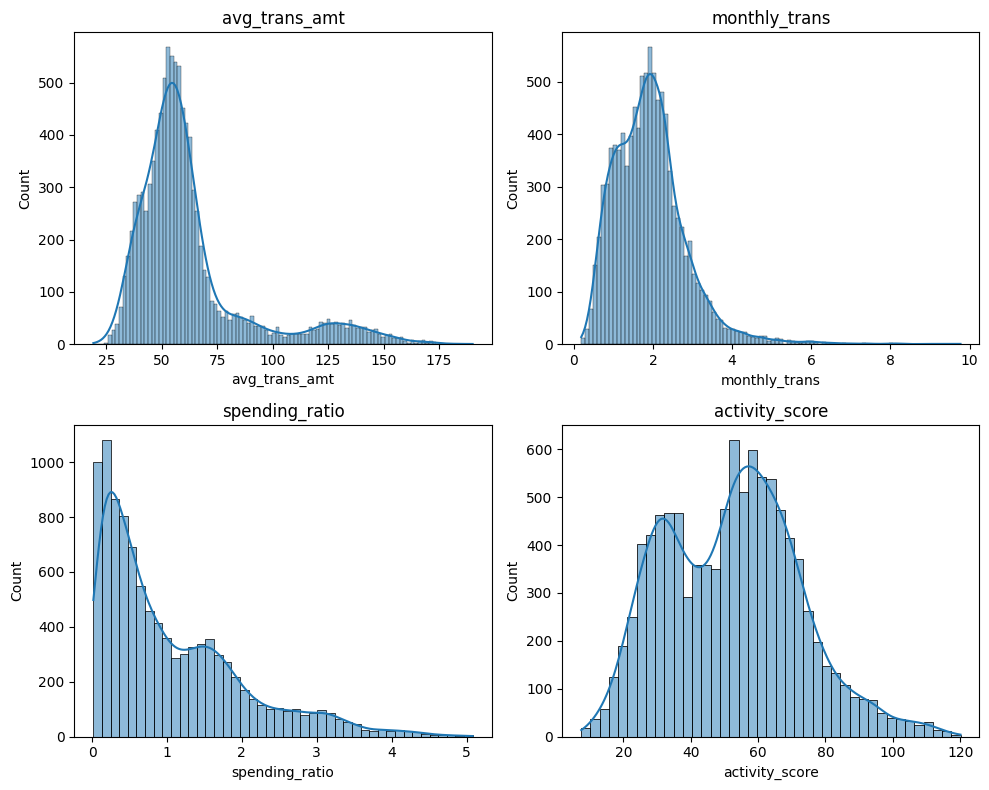

In [19]:
add_features = ['avg_trans_amt', 'monthly_trans', 'spending_ratio', 'activity_score']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, col in enumerate(add_features):
    r = i // 2
    c = i % 2
    sns.histplot(df[col], kde=True, ax=axes[r, c])
    axes[r, c].set_title(col)

plt.tight_layout()
plt.show()

In [20]:
df[add_features].describe()

,avg_trans_amt,monthly_trans,spending_ratio,activity_score
count,10127.000000,10127.000000,10127.000000,10127.000000
mean,62.612717,1.923120,1.041935,52.289515
std,26.404198,0.911977,0.937981,20.058087
min,19.137931,0.188679,0.018105,7.500000
25%,47.514573,1.272727,0.303473,35.750000
50%,55.794872,1.857143,0.727143,53.250000
75%,65.476673,2.361111,1.553307,65.833333
max,190.193182,9.769231,5.080247,120.083333


outlier, 0, inf와 같은 이상치는 보이지 않는다.

#### 기존 변수와의 상관관계 확인

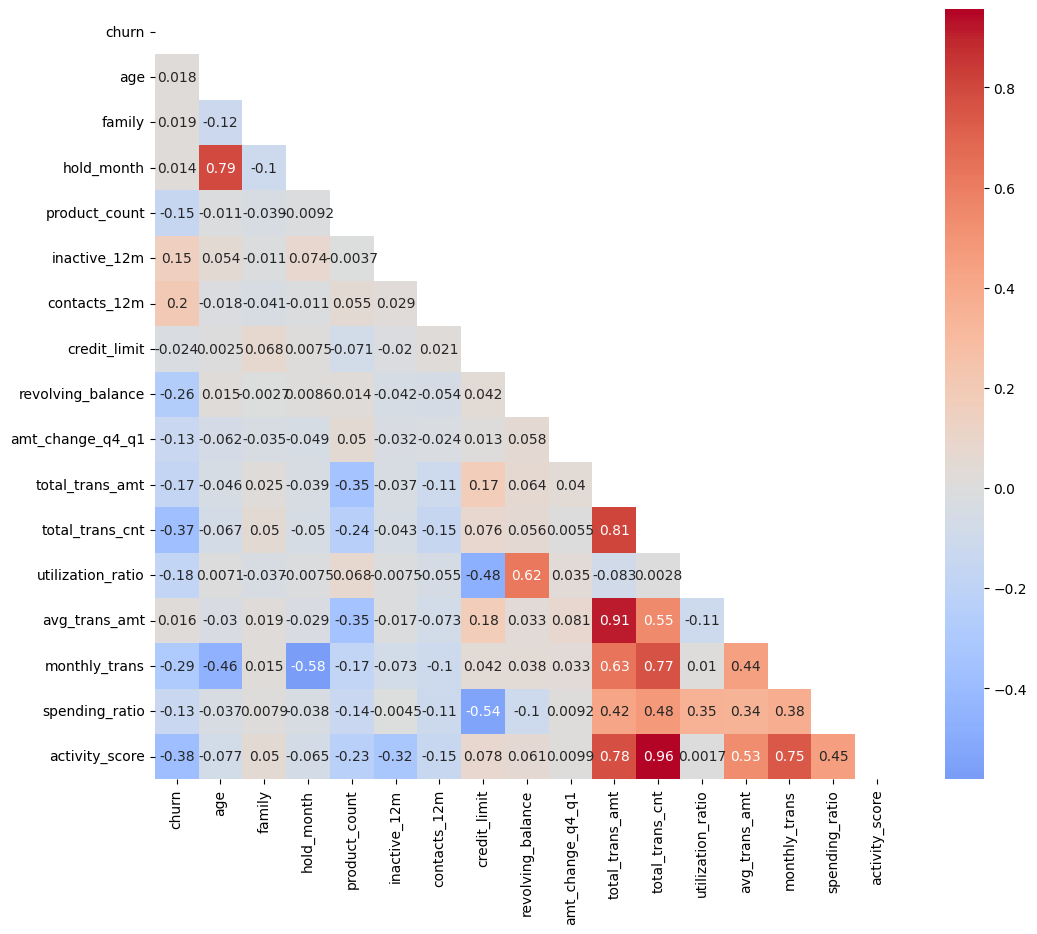

In [21]:
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr))

plt.figure(figsize=(12,10))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.show()

activity_score와 total_trans_cnt의 상관관계=0.96으로 너무 높다. churn과의 관계도 거의 동일하게 나타났다. (각각 -0.38, -0.37)

즉, activity_score가 추가적인 설명력이 거의 없으므로 삭제

In [22]:
df = df.drop(columns=['activity_score'])

이후 과정: train/test split -> one-hot encoding -> Loigstic/RandomForest/XGBoost

* 참고

https://www.ibm.com/think/topics/customer-churn

https://www.analyticsvidhya.com/blog/2021/05/customer-churn-analysis-using-machine-learning/